In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("../dataset/processed/processed_data.csv")

X = df.drop("Quality", axis=1)

y = df["Quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [3]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "Support Vector Machine": SVC()
}

In [4]:
accuracy_scores = {}

trained_models = {}

predictions = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    accuracy_scores[name] = acc

    trained_models[name] = model

    predictions[name] = pred

    print("--------------------------------")

    print(name)

    print("Accuracy :", round(acc*100,2),"%")

c:\Users\G7T28\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--------------------------------
Logistic Regression
Accuracy : 95.67 %
--------------------------------
Decision Tree
Accuracy : 100.0 %
--------------------------------
Random Forest
Accuracy : 100.0 %
--------------------------------
Support Vector Machine
Accuracy : 81.67 %


In [5]:
results = pd.DataFrame({

    "Model": accuracy_scores.keys(),

    "Accuracy": accuracy_scores.values()

})

results.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True
)

results

,Model,Accuracy
1,Decision Tree,1.000000
2,Random Forest,1.000000
0,Logistic Regression,0.956667
3,Support Vector Machine,0.816667


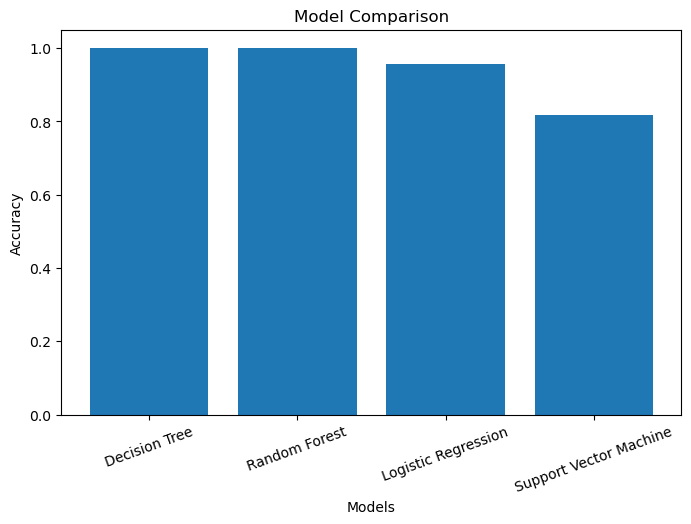

In [6]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

In [7]:
best_model_name = results.iloc[1]["Model"]

print("Best Model :", best_model_name)

Best Model : Random Forest


In [8]:
best_model = trained_models[best_model_name]

joblib.dump(best_model, "../model/best_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [9]:
for name in models.keys():

    print("\n")

    print("="*60)

    print(name)

    print("="*60)

    print(

        classification_report(

            y_test,

            predictions[name]

        )

    )



Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       242
           1       0.89      0.91      0.90        74
           2       0.98      0.98      0.98       284

    accuracy                           0.96       600
   macro avg       0.94      0.94      0.94       600
weighted avg       0.96      0.96      0.96       600



Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       242
           1       1.00      1.00      1.00        74
           2       1.00      1.00      1.00       284

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       242
           1       1.00      1.00      1.00        74
           2       1.

c:\Users\G7T28\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\G7T28\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\G7T28\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Figure size 500x500 with 0 Axes>

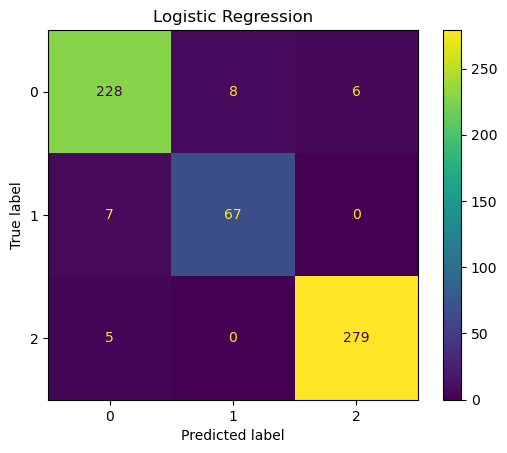

<Figure size 500x500 with 0 Axes>

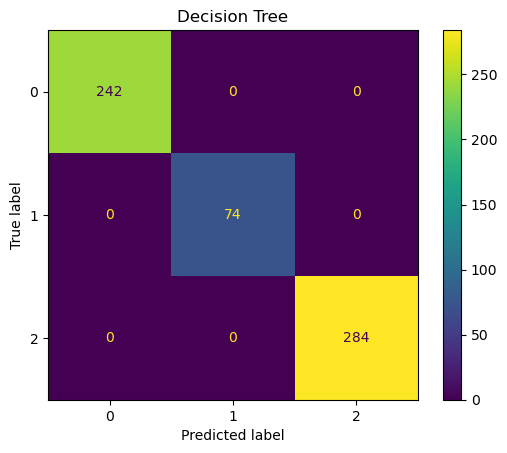

<Figure size 500x500 with 0 Axes>

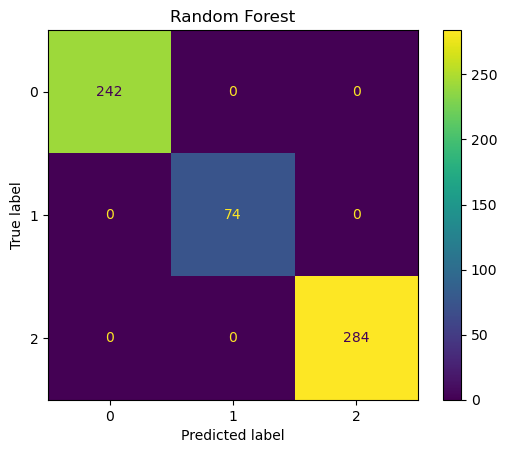

<Figure size 500x500 with 0 Axes>

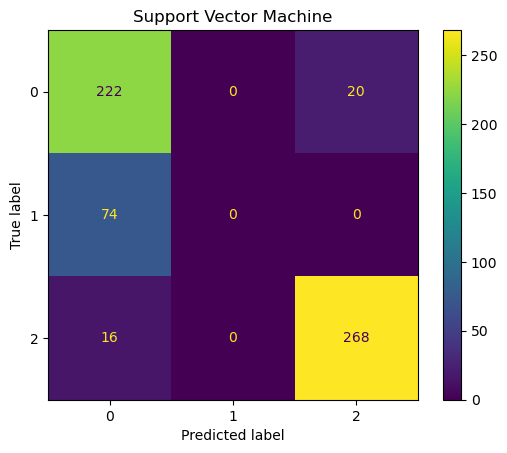

In [10]:
for name in models.keys():

    plt.figure(figsize=(5,5))

    cm = confusion_matrix(

        y_test,

        predictions[name]

    )

    disp = ConfusionMatrixDisplay(cm)

    disp.plot()

    plt.title(name)

    plt.show()

In [11]:
print("Project Pipeline Completed Successfully")

print("Best Model Saved As : best_model.pkl")

Project Pipeline Completed Successfully
Best Model Saved As : best_model.pkl


In [12]:
import joblib

joblib.dump(best_model, "../model/best_model.pkl")

['../model/best_model.pkl']